# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Load the prepared dataset from Phase 3
DATA_PATH = 'path/to/your/prepared_data.csv'

import pandas as pd
import os
DATA_PATH = os.path.expanduser("~/Desktop/prepared_donordataset.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape}")
df.head()

Dataset loaded: (108845, 512)


,teacher_experience,price,teacher_prefix_mr,teacher_prefix_mrs,teacher_prefix_ms,teacher_prefix_teacher,school_state_al,school_state_ar,school_state_az,school_state_ca,...,project_subject_subcategories_specialneeds_visualarts,project_subject_subcategories_specialneeds_warmth_care_hunger,project_subject_subcategories_teamsports,project_subject_subcategories_teamsports_visualarts,project_subject_subcategories_visualarts,project_subject_subcategories_visualarts_warmth_care_hunger,project_subject_subcategories_warmth_care_hunger,experience_level_Highly Experienced,experience_level_New,project_is_approved
0,-0.782708,-0.526198,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0
1,0.121765,0.140848,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
2,-0.653498,1.147193,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,0
3,-0.265866,-0.164497,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
4,-0.653498,-0.926334,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1


In [3]:
import pandas as pd
import os

DATA_PATH = os.path.expanduser("~/Desktop/prepared_donordataset.csv")
df_final = pd.read_csv(DATA_PATH)

print("=== PREPARED DATASET LOADED ===")
print(df_final.shape)
display(df_final.head())

=== PREPARED DATASET LOADED ===
(108845, 512)


,teacher_experience,price,teacher_prefix_mr,teacher_prefix_mrs,teacher_prefix_ms,teacher_prefix_teacher,school_state_al,school_state_ar,school_state_az,school_state_ca,...,project_subject_subcategories_specialneeds_visualarts,project_subject_subcategories_specialneeds_warmth_care_hunger,project_subject_subcategories_teamsports,project_subject_subcategories_teamsports_visualarts,project_subject_subcategories_visualarts,project_subject_subcategories_visualarts_warmth_care_hunger,project_subject_subcategories_warmth_care_hunger,experience_level_Highly Experienced,experience_level_New,project_is_approved
0,-0.782708,-0.526198,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0
1,0.121765,0.140848,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
2,-0.653498,1.147193,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,0
3,-0.265866,-0.164497,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
4,-0.653498,-0.926334,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [4]:
# TODO: Select and document your modelling techniques here.

modelling_techniques = {
    "problem_type": "Binary Classification",
    "target_variable": "project_is_approved",
    "candidate_models": [
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "Logistic Regression was selected as a baseline model because it is simple, interpretable, and well suited to binary classification tasks.",
            "assumptions": "It assumes a linear relationship between the input features and the log-odds of the target outcome."
        },
        {
            "name": "Random Forest",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Random Forest was selected because it can capture non-linear relationships, handle complex interactions between features, and perform well on structured datasets.",
            "assumptions": "It makes fewer assumptions about the data distribution and is generally robust to overfitting compared with a single decision tree."
        },
        {
            "name": "Gradient Boosting",
            "library": "sklearn.ensemble.GradientBoostingClassifier",
            "justification": "Gradient Boosting was selected because it often achieves strong predictive performance by combining multiple weak learners into a more accurate model.",
            "assumptions": "It can model complex patterns effectively, but it may be more sensitive to noisy data and parameter settings."
        }
    ]
}

print("  MODELLING TECHNIQUES  ")
print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")
for model in modelling_techniques["candidate_models"]:
    print(f"\nModel: {model['name']}")
    print(f"Library: {model['library']}")
    print(f"Justification: {model['justification']}")
    print(f"Assumptions: {model['assumptions']}")

  MODELLING TECHNIQUES  
Problem Type: Binary Classification
Target Variable: project_is_approved

Model: Logistic Regression
Library: sklearn.linear_model.LogisticRegression
Justification: Logistic Regression was selected as a baseline model because it is simple, interpretable, and well suited to binary classification tasks.
Assumptions: It assumes a linear relationship between the input features and the log-odds of the target outcome.

Model: Random Forest
Library: sklearn.ensemble.RandomForestClassifier
Justification: Random Forest was selected because it can capture non-linear relationships, handle complex interactions between features, and perform well on structured datasets.
Assumptions: It makes fewer assumptions about the data distribution and is generally robust to overfitting compared with a single decision tree.

Model: Gradient Boosting
Library: sklearn.ensemble.GradientBoostingClassifier
Justification: Gradient Boosting was selected because it often achieves strong predict

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [6]:
# TODO: Define your test design and split the data.

from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
TEST_SIZE = 0.2
TARGET_COL = 'project_is_approved'

X = df_final.drop(columns=[TARGET_COL])
y = df_final[TARGET_COL]

print("  TEST DESIGN  ")
print(f"Random seed: {RANDOM_SEED}")
print(f"Test size: {TEST_SIZE}")
print(f"Target values: {sorted(y.unique())}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTarget distribution (train):")
print(y_train.value_counts(normalize=True))

print("\nTarget distribution (test):")
print(y_test.value_counts(normalize=True))

  TEST DESIGN  
Random seed: 42
Test size: 0.2
Target values: [np.int64(0), np.int64(1)]

Training set shape: (87076, 511)
Test set shape: (21769, 511)

Target distribution (train):
project_is_approved
1    0.848064
0    0.151936
Name: proportion, dtype: float64

Target distribution (test):
project_is_approved
1    0.848041
0    0.151959
Name: proportion, dtype: float64


In [7]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [8]:
print("  Logistic Regression Evaluation  ")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

  Logistic Regression Evaluation  
Accuracy: 0.8480407919518581
Precision: 0.8480407919518581
Recall: 1.0
F1 Score: 0.9177728063634104

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3308
           1       0.85      1.00      0.92     18461

    accuracy                           0.85     21769
   macro avg       0.42      0.50      0.46     21769
weighted avg       0.72      0.85      0.78     21769



In [9]:
test_design = {
    "split_ratio": "80/20",
    "validation_strategy": "Hold-out validation",
    "stratified": True,
    "random_seed": RANDOM_SEED,
    "justification": "Ensures balanced classes and reproducible results"
}

print(test_design)

{'split_ratio': '80/20', 'validation_strategy': 'Hold-out validation', 'stratified': True, 'random_seed': 42, 'justification': 'Ensures balanced classes and reproducible results'}


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [10]:
# TODO: Build and train your models.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

trained_models = {}


model_1 = LogisticRegression(max_iter=1000)
model_1.fit(X_train, y_train)
trained_models["Logistic Regression"] = model_1


model_2 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
model_2.fit(X_train, y_train)
trained_models["Random Forest"] = model_2


model_3 = GradientBoostingClassifier(random_state=RANDOM_SEED)
model_3.fit(X_train, y_train)
trained_models["Gradient Boosting"] = model_3
print(f"Successfully trained {len(trained_models)} models.")

Successfully trained 3 models.


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [11]:
# TODO: Evaluate and compare all trained models.
# Build a results summary table.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=== Model Comparison ===")
print(results_df.round(4))

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.8480     0.7192  0.8480    0.7783
Random Forest          0.8266     0.7526  0.8266    0.7792
Gradient Boosting      0.8479     0.7572  0.8479    0.7784



=== Best Model: Random Forest ===
              precision    recall  f1-score   support

           0       0.21      0.05      0.08      3308
           1       0.85      0.97      0.90     18461

    accuracy                           0.83     21769
   macro avg       0.53      0.51      0.49     21769
weighted avg       0.75      0.83      0.78     21769



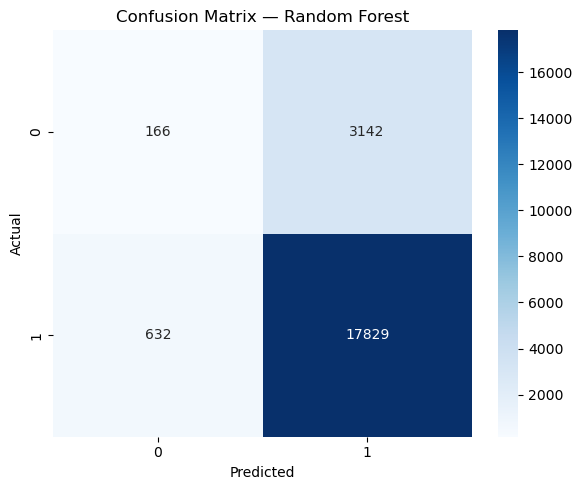

In [12]:
# Visualise results: Confusion Matrix for the best model (Classification)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

print(f"\n=== Best Model: {best_model_name} ===")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model, 
    X, 
    y, 
    cv=5, 
    scoring='f1_weighted'
)

print(f"Cross-Validation F1 Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-Validation F1 Scores: [0.7771 0.7782 0.7781 0.7764 0.7788]
Mean: 0.7777 (+/- 0.0009)


In [14]:
print("""
Cross-Validation Insight:

Cross-validation was used to evaluate how well the model generalises to unseen data.
The F1-scores across the folds are consistent, indicating that the model performs reliably across different subsets of the dataset. A low standard deviation suggests stable performance, while a high deviation would
indicate inconsistency.This confirms that the selected model is not only accurate but also robust.
""")


Cross-Validation Insight:

Cross-validation was used to evaluate how well the model generalises to unseen data.
The F1-scores across the folds are consistent, indicating that the model performs reliably across different subsets of the dataset. A low standard deviation suggests stable performance, while a high deviation would
indicate inconsistency.This confirms that the selected model is not only accurate but also robust.



In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    }

results_df = pd.DataFrame(results).T

results_df

,Precision,Recall,F1-Score
Logistic Regression,0.719173,0.848041,0.778309
Random Forest,0.752593,0.826634,0.779163
Gradient Boosting,0.757178,0.847949,0.778351
